In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('retail_sales_dataset.csv')

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.dropna(inplace=True)

In [11]:
print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [16]:
df.columns = df.columns.str.strip()

In [18]:
print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [21]:
df['Total Amount'] = df['Quantity'] * df['Price per Unit']

In [22]:
print("--- Descriptive Statistics ---")
print(df.describe())

--- Descriptive Statistics ---
       Transaction ID                           Date         Age     Quantity  \
count     1000.000000                           1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000256    41.39200     2.514000   
min          1.000000            2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000            2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000            2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000            2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000            2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                            NaN    13.68143     1.132734   

       Price per Unit  Total Amount  
count     1000.000000   1000.000000  
mean       179.890000    456.000000  
min         25.000000     25.000000  
25%         30.000000     60.000000  
50%         50.000000    135.000000  
75%        

In [23]:
df['Month'] = df['Date'].dt.to_period('M')

In [24]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()
print(monthly_sales)

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


In [26]:
product_analysis = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print(product_analysis)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


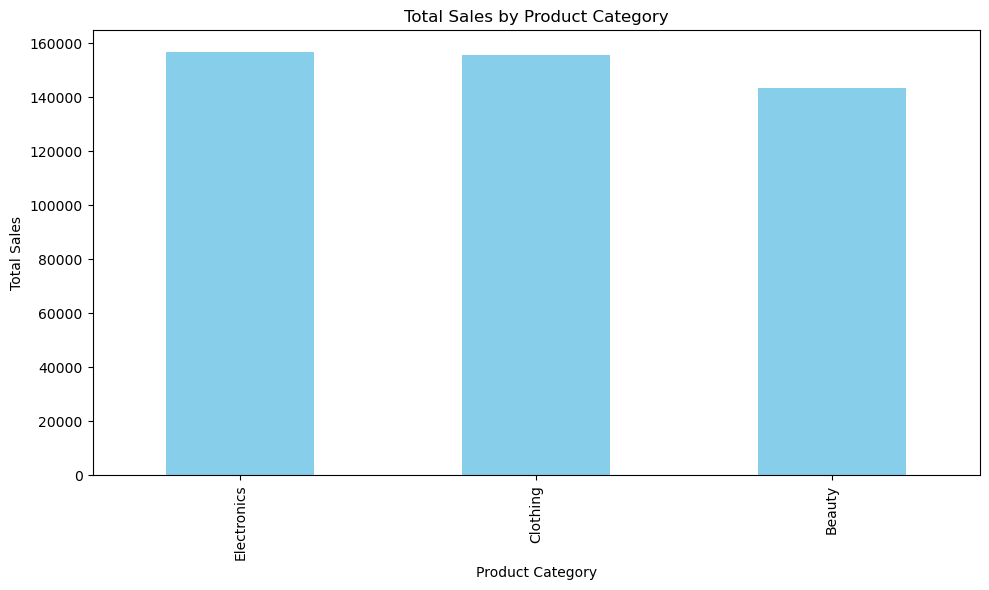

In [27]:
plt.figure(figsize=(10, 6))
product_analysis.plot(kind='bar', color='skyblue')

plt.title('Total Sales by Product Category')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.savefig('project_analysis.png')
plt.show()

In [28]:
top_category = product_analysis.idxmax()
print(f"Recommendation 1: Focus marketing efforts on the '{top_category}' category.")

Recommendation 1: Focus marketing efforts on the 'Electronics' category.


In [29]:
if monthly_sales.iloc[-1] < monthly_sales.mean():
    print("Recommendation 2: Sales were low in the last month; consider promotional discounts.")
else:
    print("Recommendation 2: Maintain current sales strategy.")

Recommendation 2: Sales were low in the last month; consider promotional discounts.
